In [1]:
from embedding.graph import Graph
from embedding.poincare import PoincareDisk
from embedding.embedding import Embedding

import torch
from networkit import vizbridges
from matplotlib import pyplot as plt

In [2]:
# create graph and disk
G = Graph()
G.create_random(num_nodes=100, min_b=5, max_b=25, mean=15.0, dev=5.0)
#vizbridges.widgetFromGraph(G.graph)

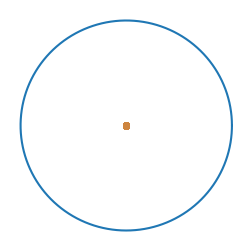

In [5]:
D = PoincareDisk()
D.sample_random(num_points=100, radius=0.001)
D.visualize(size=3, circle=True, numbers=False)

In [6]:
# use them to create embedding object
E = Embedding(G, D)
distortion_initial = E.normal_avg_distortion_vec(E._disk.data_points)
print(f"Distortion after initialization: {distortion_initial}.")

Distortion after initialization: 169.47840066522812.


In [7]:
# start optimization
epochs = 5
distortions = E.RSGD(num_epochs=epochs)

Distortion after 5. epoch: 9.776983821680629.


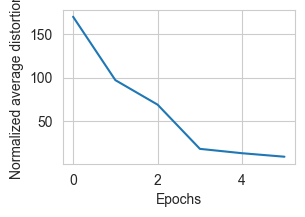

In [8]:
# show distortions during optimization process
plt.figure(figsize=(3, 2))
plt.plot(torch.arange(epochs+1), distortions)
plt.xlabel("Epochs")
plt.ylabel("Normalized average distortion")
plt.show()

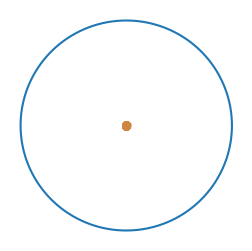

In [9]:
E._disk.visualize(size=5, circle=True, numbers=False)